# prep

In [1]:
account_path = '/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/'

In [2]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive/')
from google.colab import auth
auth.authenticate_user()

# load packages - basics
!pip install pynrrd
import os
import csv
import numpy as np
import pandas as pd
import math
import time
import json
import nrrd

Mounted at /content/drive/


In [3]:
# load packages - stats
!pip install scikit-posthocs
import scipy
from scipy import io
from scipy.fftpack import rfft, irfft, fftfreq
import scipy.stats as stats
from scipy.stats import zscore

import statsmodels.api as sm
import statsmodels.formula.api as smf
import scikit_posthocs as scikit
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels

import random
from random import randrange, shuffle
import itertools
from itertools import combinations
import sklearn
from sklearn.decomposition import PCA, FastICA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

In [4]:
# load packages - plotting and template settings
import matplotlib as mpl
from matplotlib import pyplot as plt
%matplotlib inline

from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## fcn.

In [5]:
import gspread
from google.auth import default

def read_metadata(gsheet_url,tab_name):
  """This script reads information in a tab in the Google sheet, where metadata for each experiment is stored.
  """
  # import gspread
  # from google.auth import default

  # reading in google sheet with experimental details
  creds, _ = default()
  gc = gspread.authorize(creds)

  # insert URl of gsheet, specify worksheets as different variables
  wb = gc.open_by_url(gsheet_url)
  exps = wb.worksheet(tab_name)

  #
  all_data = pd.DataFrame(exps.get_all_records())
  metadata = all_data.set_index('experiment')
  display(all_data)

  return metadata

## config

In [6]:
# figures output parameters
mpl.rcParams['lines.linewidth'] = 1        # default line width
mpl.rcParams['patch.linewidth'] = 0
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

# Set global Matplotlib parameters for PDF output
mpl.rcParams['pdf.fonttype'] = 42          # Use TrueType fonts (editable text)

mpl.rcParams['figure.figsize'] = (4,3)     # Default figure size in inches
mpl.rcParams['axes.titlesize'] = 16        # Title font size
mpl.rcParams['axes.labelsize'] = 14        # Axis label font size
mpl.rcParams['xtick.labelsize'] = 10       # X-axis tick label size
mpl.rcParams['ytick.labelsize'] = 10       # Y-axis tick label size
mpl.rcParams['legend.fontsize'] = 8        # Legend font size
mpl.rcParams['savefig.dpi'] = 300          # DPI for high-quality export (relevant for raster elements)
mpl.rcParams['savefig.transparent'] = True # Ensures background is transparent
sns.set(style="white",font_scale=1)     # global scaling of all texts
mpl.rcParams['xtick.bottom'] = True        # make sure ticks visible
mpl.rcParams['ytick.left'] = True

mpl.rcParams['xtick.major.width'] = 0.5    # X-axis major tick width
mpl.rcParams['ytick.major.width'] = 0.5    # Y-axis major tick width
mpl.rcParams['axes.linewidth'] = 0.5       # Axis line width

from cycler import cycler
# remove red from the default colors
mpl.rcParams['axes.prop_cycle'] = cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

In [8]:
figure_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/'
csv_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v8/csvs/'

# Data: loom

In [9]:
# directories for the data and analysis
gsheet = 'https://docs.google.com/spreadsheets/d/1zJNHJJECC8FGB9S8tIh6QnoRihyoTZyKAgS-SE8ojwU/edit?gid=1421697431#gid=1421697431'
tab_name = 'loom_gsize'

experiment_class = 'Loom escape - group size'
path = account_path + 'Yu_escape_paper/Behavior/' + experiment_class
data_path = path + '/Data/'
save_path = path + '/Analysis/'

metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index

,experiment,fish_num,rig_mm,vid_px,rig_coord,loomX,loomZ,loom_dur
0,jy_240311_s16,1,265,945,"25,27;981,27;981,977;25,977",15,-30,6
1,jy_240311_s18,1,265,945,"25,27;981,27;981,977;25,977",15,-30,4
2,jy_240318_s20,1,265,927,"28,43;967,43;967,977;28,977",-15,30,5
3,jy_240318_s21,1,265,927,"28,43;967,43;967,977;28,977",-15,-30,3
4,jy_240318_s22,1,265,927,"28,43;967,43;967,977;28,977",-15,30,4
...,...,...,...,...,...,...,...,...
93,jy_240516_s10,8,265,904,"48,51;965,51;965,955;48,955",15,-30,3
94,jy_240516_s11,8,265,904,"48,51;965,51;965,955;48,955",15,30,3
95,jy_240516_s12,8,265,904,"48,51;965,51;965,955;48,955",-15,-30,3
96,jy_240516_s13,8,265,904,"48,51;965,51;965,955;48,955",-15,30,5


## group size color scheme

['#b6b6d8', '#8682bc', '#61409b', '#3f007d']


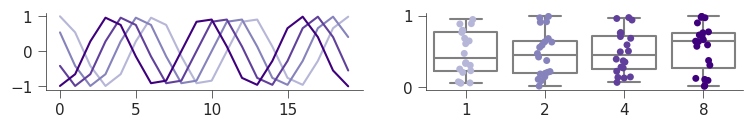

In [10]:
# RGB hex values theme - for summary stats plots
group_names = [1,2,4,8]; group_num = len(group_names)

# get the RGBA from normalized colormap axis
viridis_colors = [cm.Purples(i/(group_num+1)) for i in range(2,group_num+2)]
hex_colors = [f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}' for r, g, b, _ in viridis_colors] # Convert RGBA to HEX
print(hex_colors) # ['#abcfe5', '#6aadd5', '#3787c0', '#0f5ba3', '#08306b']

# validate colors settings work with both major plotting packages
plt.figure(figsize=[9,1]); plt.subplot(121);
for igs, gs in enumerate(group_names): plt.plot(np.cos(np.arange(igs,igs+20)),c=hex_colors[igs]);
tmp = {n: np.random.random(20) for n in group_names};
plt.subplot(122); sns.boxplot(data=tmp,fill=False,color='gray'); sns.stripplot(data=tmp,palette=hex_colors); sns.despine();
plt.show()

# 1a - loom escape setup

# 1b - example trajectory (4)


Group: jy_240320_s27 4 fish
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/1b


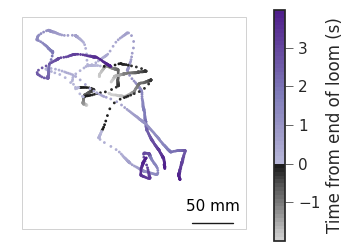

,f1_x,f1_y,f2_x,f2_y,f3_x,f3_y,f4_x,f4_y
0,310.071790,588.343591,360.220575,712.308179,407.989307,688.429749,398.622357,639.817981
1,308.693048,588.481812,360.259381,712.515771,410.164099,691.593530,400.233002,639.274792
2,308.395111,588.566724,360.238983,713.315356,411.798975,694.636572,401.982074,638.040173
3,308.130267,588.679126,360.239240,714.786658,412.796869,696.397644,405.802808,635.323743
4,307.953577,588.786011,360.258398,716.292566,414.266962,697.958398,410.733868,633.533215
...,...,...,...,...,...,...,...,...
358,623.865645,320.403542,684.615662,269.088522,400.286487,760.479089,542.978760,350.978906
359,623.889136,320.234735,684.802563,268.405963,401.151306,759.739636,544.656006,354.009802
360,623.932886,319.493127,684.900659,267.971790,402.542010,759.534827,546.197278,355.781348
361,624.020654,317.379272,684.935327,267.182672,404.064514,758.527209,547.841333,358.018750


In [ ]:
subpanel = '1b'
rep_experiments = ['jy_240320_s27'] # loom X, Z = 15, 30 (upper right corner from top down view)
samples_x = []; samples_y = [] # for csv saving

for exp in rep_experiments:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]; loom_dur = metadata.loom_dur[exp]
  rig_mm = metadata.rig_mm[exp]; rig_coord = metadata.rig_coord[exp] # xy of four corners from top left, clockwise
  c1,c2,c3,c4 = rig_coord.split(';');
  x1,y1 = [int(c) for c in c1.split(',')]; x2,y2 = [int(c) for c in c2.split(',')]; x3,y3 = [int(c) for c in c3.split(',')]; x4,y4 = [int(c) for c in c4.split(',')]
  vid_px = (abs(x1-x2)+abs(y1-y4))/2; scale = rig_mm/vid_px # mm per pixel

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  fish_num, scale, fps, frame_num =  data['fish_num'], data['scale'], data['fps'], data['frame_num']
  f_speed, f_bodylength_mm = data['f_speed']*scale, data['f_bodylength_mm']
  f_speed_bd = np.array([(sp/bd) for sp, bd in zip(f_speed, f_bodylength_mm)])
  f_x, f_y = data['f_x'], data['f_y']

  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_sec, loom_frames, loom_len = data['loom_sec'], data['loom_frames'], data['loom_len']
  loom_on = loom_frames[0]; loom_off = loom_on + loom_len
  loom_x, loom_y = data['loom_x'], data['loom_y']

  print('\nGroup:', exp, fish_num, 'fish')
  # windows of plotting # 2+4 sec peri loom
  pre, post = 2, 4 # in sec before and after tap
  start = loom_off-int(pre*fps); stop = loom_off+int(post*fps)

  # trajectories # colored by time position
  fig, ax = plt.subplots(figsize=[4,3])
  ax.add_patch(patches.Rectangle((x1,y1),abs(y1-y4),abs(x1-x2),edgecolor=(0,0,0,0.25), facecolor='none', linewidth=0.5))

  # Define custom hybrid colormap
  cmap1 = plt.colormaps['Greys']; cmap2 = plt.colormaps['Purples']
  colors = np.vstack((cmap1(np.linspace(0.3,0.9,20)), cmap2(np.linspace(0.4,0.9,40)))) # ratio of cmap used, amount of slicing
  combined_cmap = mcolors.ListedColormap(colors);
  combined_time = (np.arange(start,stop)-loom_off)/fps

  for f in range(fish_num):
    plt.scatter(f_x[f][start:stop:2],f_y[f][start:stop:2],c=combined_time[::2],cmap=combined_cmap,s=1)
    samples_x.append(f_x[f][start:stop:2]);
    samples_y.append(f_y[f][start:stop:2])
  plt.colorbar(label='Time from end of loom (s)')

  plt.xlim(0,1000); plt.ylim(0,1000); plt.xticks([]); plt.yticks([])
  # scale bar
  x = np.arange(900-(1000/6),900); y = np.ones(len(x))*80
  plt.plot(x,y,c='k',linewidth=1);
  plt.text(np.mean(x), np.mean(y)+50,'50 mm', ha='center', fontsize=11, color='black')
  for spine in ax.spines.values(): spine.set_visible(False)
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
  plt.show()

# save source data into csv - for time series, save out the visible part
series_dict = {}
for i, (xx, yy) in enumerate(zip(samples_x, samples_y)):
  col_name = f"f{i+1}_x"; series_dict[col_name] = pd.Series(xx)  # auto-fills NaN
  col_name = f"f{i+1}_y"; series_dict[col_name] = pd.Series(yy)

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# 1c - Δspeed (4)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/1c


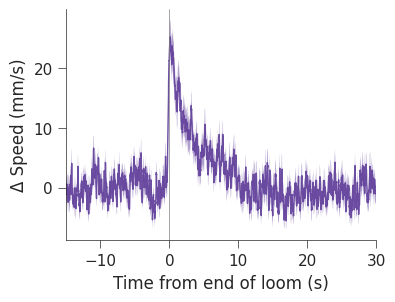

N = [20]


,group_1,group_2,group_3,group_4,group_5,group_6,group_7,group_8,group_9,group_10,...,group_71,group_72,group_73,group_74,group_75,group_76,group_77,group_78,group_79,group_80
0,4.467548,-10.323124,0.357157,-4.961854,-9.107068,3.610079,19.178398,9.744792,-11.328112,-11.253546,...,-20.826743,12.222931,3.166177,-17.929341,8.254326,9.310370,0.888757,-18.974829,10.176743,-9.265441
1,2.531194,-10.874823,4.391041,-5.590631,-9.829097,3.000774,17.930065,7.911450,-11.651334,-11.586960,...,-21.342333,7.307915,0.383574,-18.429961,9.373511,14.671945,-0.986267,-19.276862,9.335666,-8.954614
2,3.740692,-11.120481,7.381830,-5.784425,-10.153332,2.662768,17.144643,3.819862,-11.452556,-12.136465,...,-21.456584,3.583938,-1.676981,-17.684197,10.234880,20.145705,-2.865493,-19.222270,9.849228,-8.769745
3,4.193565,-11.694391,10.541426,-5.687615,-10.079773,1.077658,14.758710,1.284109,-11.064129,-12.147275,...,-21.023092,0.920619,-3.015487,-16.714271,10.838433,25.731649,-3.467741,-19.340555,9.690595,-8.763255
4,3.889812,-11.907611,13.852284,-5.300199,-9.608420,-0.187424,11.583294,0.824111,-10.735238,-13.002984,...,-20.428153,-0.682042,-4.411033,-16.611829,11.184170,30.223946,-3.488619,-19.250717,8.816341,-8.375488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5440,-6.200780,16.359944,-17.086703,-7.642918,-8.008548,8.818171,-1.343619,-11.356589,-8.945082,2.474632,...,-16.696211,-21.551109,-1.041471,9.277203,-18.218786,-0.170167,-11.675633,-10.056375,0.245645,-3.952721
5441,-6.028958,20.272460,-17.066051,-7.472341,-8.424574,6.760384,-1.042350,-10.870643,-7.856270,2.382199,...,-17.128151,-21.473835,-5.274624,9.304440,-18.222393,1.913520,-12.619823,-11.352445,-0.816546,-2.050553
5442,-6.130359,25.177162,-17.047498,-7.623776,-8.949322,4.784269,-0.506086,-11.128633,-6.160260,2.891661,...,-16.845527,-21.479130,-7.641103,11.073005,-19.540860,4.296183,-12.716120,-12.668981,-2.645370,-0.731514
5443,-6.142966,28.407691,-17.185426,-7.232176,-9.315918,2.889826,-0.927071,-11.152158,-3.857051,3.014919,...,-17.323718,-21.564155,-9.042965,8.528740,-19.930273,6.169376,-11.702699,-12.801633,-4.566718,-0.602272


In [ ]:
subpanel = '1c'
group_sizes = [4]; group_values = {n: [] for n in group_sizes}
hex_colors = ['#61409b']

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp];
  if fish_num !=4: continue

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale = data['scale']
  f_speed = data['f_speed']*scale
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len

  # get 30-sec x(121 fps) before and after tap get same legnth of arrays
  for f in range(fish_num):
    group_values[fish_num].append((f_speed[f][loom_off-int(30*121):loom_off+int(30*121)])-np.mean(f_speed[f][loom_off-int(30*121):loom_off]))

# make time_sec relative to tap for plotting
pre = np.linspace(-30,0,30*121); post = np.linspace(0,30,30*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

# PLOT # mean+sem
plt.figure(figsize=[4,3])
for i, gs in enumerate(group_sizes):
  plt.plot(rel_sec,np.mean(group_values[gs],axis=0),linewidth=1,alpha=0.9, label=f'group of {gs}', color=hex_colors[i])
  plt.fill_between(rel_sec,np.mean(group_values[gs],axis=0)-stats.sem(group_values[gs],axis=0,nan_policy='omit'), \
                  np.nanmean(group_values[gs],axis=0)+stats.sem(group_values[gs],axis=0, nan_policy='omit'),alpha=0.5, color=hex_colors[i],linewidth=0)

plt.axvline(0,c='grey',linestyle='-',linewidth=0.5);
plt.xlim(-15,30);
plt.xlabel('Time from end of loom (s)'); plt.ylabel('Δ Speed (mm/s)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f"N = {[int(len(group_values[g])/g) for g in group_sizes]}")

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -15, 30; fps = 121

series_dict = {}
for group, samples in group_values.items():
  for i, sample in enumerate(samples):
    col_name = f"fish_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])  # auto-fills NaN

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# 1d - Δspeed time series (1 vs 4)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/1d


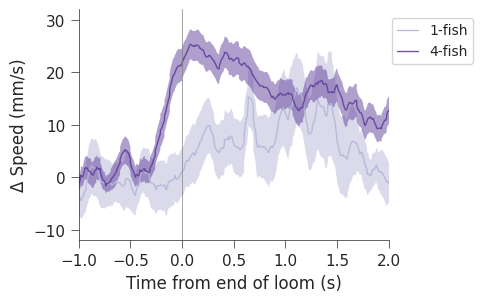

N = [18, 20]


,1fish_1,1fish_2,1fish_3,1fish_4,1fish_5,1fish_6,1fish_7,1fish_8,1fish_9,1fish_10,...,4fish_71,4fish_72,4fish_73,4fish_74,4fish_75,4fish_76,4fish_77,4fish_78,4fish_79,4fish_80
0,2.144487,1.143382,-14.030848,2.402840,-4.530696,17.862135,27.504797,21.026120,0.350765,-17.996601,...,21.812726,-2.090027,11.134507,1.169258,-6.542166,-3.490020,4.518805,-17.795778,-11.312310,8.207481
1,1.827538,1.193161,-13.949455,5.363882,-3.984653,19.456692,27.504797,16.839374,-0.907746,-17.374374,...,26.746360,-3.347276,9.187858,4.202389,-6.598253,-4.969284,9.750820,-17.905938,-19.795455,5.371127
2,-0.087710,0.081868,-10.095660,7.490787,-4.923797,23.170989,27.504797,6.940640,-2.013502,-17.632306,...,27.546516,-4.886813,7.923905,6.801639,-6.058746,-5.946026,14.013376,-18.016091,-28.382392,3.153693
3,-1.662199,0.220676,-3.119730,10.239566,-5.508921,26.742546,27.504797,-3.619585,-1.189834,-17.999867,...,28.346672,-6.708637,6.564212,8.967009,-4.923645,-3.870356,17.118720,-18.016565,-28.796149,3.186658
4,-2.895930,1.178133,3.983854,12.782929,-5.613202,28.679305,27.504797,-8.322090,0.313897,-18.063591,...,28.794130,-8.812749,5.108778,10.698499,-4.474264,-0.219444,19.470526,-19.276430,-29.484569,3.478821
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,-6.918594,-2.981021,-0.148426,13.145150,8.019042,1.204470,-4.642693,-5.288295,-6.255257,-13.733352,...,21.176479,-24.751704,-7.210211,-8.677507,-9.027154,-12.385360,-18.556472,-2.173839,-26.546242,-5.886227
359,-6.477405,-3.693861,-1.530506,13.222711,6.439592,1.597298,-15.651708,-4.786343,-6.317937,-11.888041,...,21.062269,-24.993584,-4.873314,-6.147918,-9.398042,-10.596234,-18.256789,-2.823004,-27.162190,-6.635831
360,-7.705630,-4.122867,-2.207596,13.751988,4.363669,2.153649,-22.121575,-4.712794,-6.380618,-10.671636,...,20.948060,-24.054460,-2.238040,-2.698642,-10.171368,-8.559232,-18.967547,-6.036724,-27.599812,-8.656578
361,-7.815678,-4.434018,-3.272011,14.732982,2.189819,4.256862,-24.052296,-5.067648,-6.443298,-8.721938,...,20.833850,-23.488504,0.695611,1.670318,-11.347133,-6.150234,-19.441177,-7.224772,-28.479030,-11.126540


In [ ]:
subpanel = '1d'
group_sizes = [1,4]; group_values = {n: [] for n in group_sizes}
hex_colors = ['#b6b6d8', '#61409b']

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp];
  if fish_num !=1 and fish_num !=4: continue

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale, f_bodylength_mm = data['scale'], data['f_bodylength_mm']
  f_speed = data['f_speed']*scale
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len

  # get 30-sec x(121 fps) before and after tap get same legnth of arrays
  for f in range(fish_num):
    # subtract baseline (30-sec pre tap) to get change of speed
    group_values[fish_num].append((f_speed[f][loom_off-int(30*121):loom_off+int(30*121)])-np.mean(f_speed[f][loom_off-int(30*121):loom_off]))


# make time_sec relative to tap for plotting
pre = np.linspace(-30,0,30*121); post = np.linspace(0,30,30*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

# PLOT # mean+sem
plt.figure(figsize=[4,3])
for i, gs in enumerate(group_sizes):
  plt.plot(rel_sec,np.mean(group_values[gs],axis=0),linewidth=1,alpha=0.9, label=f'{gs}-fish', color=hex_colors[i])
  plt.fill_between(rel_sec,np.mean(group_values[gs],axis=0)-stats.sem(group_values[gs],axis=0,nan_policy='omit'), \
                  np.nanmean(group_values[gs],axis=0)+stats.sem(group_values[gs],axis=0, nan_policy='omit'),alpha=0.5, color=hex_colors[i],linewidth=0)

plt.axvline(0,c='grey',linestyle='-',linewidth=0.5);
plt.legend(bbox_to_anchor=(1,0.75),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
plt.xlim(-1,2); plt.ylim(-12,32)
plt.xlabel('Time from end of loom (s)'); plt.ylabel('Δ Speed (mm/s)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f"N = {[int(len(group_values[g])/g) for g in group_sizes]}")

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -1, 2; fps = 121

series_dict = {}
for group, samples in group_values.items():
  for i, sample in enumerate(samples):
    col_name = f"{group}fish_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])  # auto-fills NaN

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# 1e - Δspeed stats (1 vs 4)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/1e


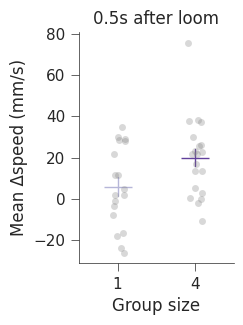

Ns, means, and  sems for data:
1: (N=18) 6.003, 4.637
4: (N=20) 20.083, 4.300

Normality test (Shapiro-Wilk):
Group 1: W = 0.938, p = 2.6580157297e-01
Group 4: W = 0.924, p = 1.1603211303e-01
all groups are normally distributed → use parametric test.

T-test: t = -2.229, p = 3.2120308988e-02


,1fish,4fish
0,34.885624,37.934065
1,1.872841,21.611160
2,21.978722,17.186722
3,28.917541,13.417883
4,1.730150,0.295134
5,27.929350,37.216836
6,-16.213517,0.111119
7,11.834323,26.056878
8,-17.949656,25.845571
9,-3.444739,13.819652


In [ ]:
subpanel = '1e'
window_of_interest = [0.5] # sec
rng = np.random.default_rng(seed=39)

for woi in window_of_interest:

  # DATA
  group_sizes = [1,4]; group_values = {n: [] for n in group_sizes}
  hex_colors = ['#b6b6d8', '#61409b']

  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num not in group_sizes: continue

    # load data
    if os.path.exists(load_path + 'lev0_basics.npz') == False: continue
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    f_speed =  data['f_speed']*scale
    data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
    loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len

    # compare pre and post loom 500-ms
    window = int(fps*woi)

    pre_speeds = [np.nanmean(i[loom_off-int(30*fps):loom_off]) for i in f_speed]
    post_speeds = [i[loom_off:loom_off+window] for i in f_speed]

    if fish_num == 1:
      group_values[fish_num].append(np.nanmean(post_speeds[0])-np.nanmean(pre_speeds[0]))
    else:
      # randomly pull one from the group
      f = rng.choice(np.arange(fish_num))
      group_values[fish_num].append((np.nanmean(post_speeds[f])-np.nanmean(pre_speeds[f])))

  # plot
  plt.figure(figsize=[2,3])
  sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5)
  sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
  plt.xlabel('Group size'); plt.ylabel(f'Mean Δspeed (mm/s)')
  sns.despine(); plt.title(f'{woi}s after loom')
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
  plt.show()

  # stats
  group_sizes = list(group_values.keys())
  groups = group_values.keys()
  summary_data = group_values.values()
  print("Ns, means, and  sems for data:")
  for id, s in enumerate(summary_data):
    print(f'{group_sizes[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

  ## -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(groups, summary_data):
    stat, p = stats.shapiro(data)
    normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
    print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.10e}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values());
  if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
  else: print("not all groups are normally distributed \u2192 use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = len(groups);
  if unique_groups == 2:
    groups = list(groups); summary_data = group_values
    #  Two groups: t-test or Mann-Whitney
    if is_normal:
      stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
    else:
      stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

  elif unique_groups > 2:
    if is_normal: # One-way ANOVA
      summary_data = list(group_values.values())
      groups = list(group_values.keys())
      df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
      # Define the formula
      formula = 'data ~ group'
      # Fit the model
      model = smf.ols(formula, data=df).fit()
      anova_table = sm.stats.anova_lm(model, typ=2)
      print("\nOne-way ANOVA:\n", anova_table)
      if anova_table['PR(>F)'][0] < 0.05:
        flat_data = [val for sublist in summary_data for val in sublist]
        groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
        tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
        print("\nTukey's HSD post hoc test:\n", tukey.summary())
        for res in tukey._results_table.data[1:]:
          g1, g2, p = res[0], res[1], res[4]

    else: # Kruskal-Wallis test
      stat, p = stats.kruskal(*summary_data)
      print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
      if p < 0.05:
        # Dunn's post hoc test with Bonferroni correction
        data_for_dunn = list(summary_data); group_for_dunn = list(groups)
        dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
        print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
        print(dunn)

  # save source data into csv
  series_dict = {}
  for key, values in group_values.items(): series_dict[f'{key}fish'] = pd.Series(values)

  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'.csv', index=False)

# 1f - post loom travel dist stats (1 vs 4)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/1f


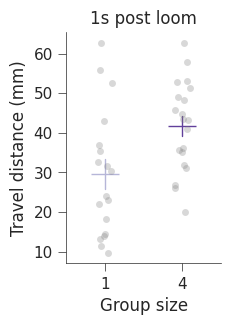

Ns, means, and  sems for data:
1: (N=18) 29.552, 3.767
4: (N=20) 41.830, 2.531

Normality test (Shapiro-Wilk):
Group 1: W = 0.927, p = 1.7135254121e-01
Group 4: W = 0.985, p = 9.8303459310e-01
all groups are normally distributed → use parametric test.

T-test: t = -2.754, p = 9.1659771284e-03


,1fish,4fish
0,36.961107,44.774410
1,11.497850,26.122215
2,35.503737,43.498260
3,62.784449,31.920387
4,18.235538,26.766992
5,21.929416,43.196806
6,32.643109,57.924947
7,30.333465,45.675317
8,31.580625,48.980590
9,13.996310,35.699201


In [ ]:
subpanel = '1f'
window_of_interest = [1] # sec
group_sizes = [1,4]

for woi in window_of_interest:

  # DATA
  group_sizes = [1,4]; group_values = {n: [] for n in group_sizes}
  hex_colors = ['#b6b6d8', '#61409b']

  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num not in group_sizes: continue

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    f_speed =  data['f_speed']*scale
    data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
    loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len

    # compare pre and post tap 500-ms
    window = int(fps*woi); dt = 1/fps
    f_travel = [np.trapezoid(sp[loom_off:loom_off+window],dx=dt) for sp in f_speed]

    # take mean of the group if >1 fish
    if fish_num == 1:
      group_values[fish_num].append(f_travel[0])
    else:
      group_values[fish_num].append(np.mean([f_travel[f] for f in range(fish_num)]))

  # plot
  plt.figure(figsize=[2,3])
  sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5) #,legend=group_values.keys());
  sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
  plt.xlabel('Group size'); plt.ylabel('Travel distance (mm)')
  sns.despine(); plt.title(f'{woi}s after loom')
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
  plt.show()

  # stats
  group_sizes = list(group_values.keys())
  groups = group_values.keys()
  summary_data = group_values.values()
  print("Ns, means, and  sems for data:")
  for id, s in enumerate(summary_data):
    print(f'{group_sizes[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

  ## -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(groups, summary_data):
    stat, p = stats.shapiro(data)
    normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
    print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.10e}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values());
  if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
  else: print("not all groups are normally distributed \u2192 use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = len(groups);
  if unique_groups == 2:
    groups = list(groups); summary_data = group_values
    #  Two groups: t-test or Mann-Whitney
    if is_normal:
      stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
    else:
      stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

  elif unique_groups > 2:
    if is_normal: # One-way ANOVA
      summary_data = list(group_values.values())
      groups = list(group_values.keys())
      df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
      # Define the formula
      formula = 'data ~ group'
      # Fit the model
      model = smf.ols(formula, data=df).fit()
      anova_table = sm.stats.anova_lm(model, typ=2)
      print("\nOne-way ANOVA:\n", anova_table)
      if anova_table['PR(>F)'][0] < 0.05:
        flat_data = [val for sublist in summary_data for val in sublist]
        groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
        tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
        print("\nTukey's HSD post hoc test:\n", tukey.summary())
        for res in tukey._results_table.data[1:]:
          g1, g2, p = res[0], res[1], res[4]

    else: # Kruskal-Wallis test
      stat, p = stats.kruskal(*summary_data)
      print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
      if p < 0.05:
        # Dunn's post hoc test with Bonferroni correction
        data_for_dunn = list(summary_data); group_for_dunn = list(groups)
        dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
        print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
        print(dunn)

  # save source data into csv
  series_dict = {}
  for key, values in group_values.items(): series_dict[f'{key}fish'] = pd.Series(values)

  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'.csv', index=False)

# 1g - median of turning CDF

In [11]:
# take each fish instead of group means for metric

group_sizes = [4]; group_values = {n: [] for n in group_sizes}
hex_colors = ['#61409b']

dt_sec = 0.05  # sampling interval for delta heading
fps = 121      # frames per second (adjust as needed)

# stimulus-relative windows (in sec)
window_times = {f'{i:.2f}s':(i,i+0.1) for i in np.arange(-1,1.1,0.1)}

# prepare pooling structure
pooled_dtheta = {g: {w: [] for w in window_times} for g in group_sizes}
metrics = {g: {w: [] for w in window_times} for g in group_sizes}

for exp in experiments:
  load_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]
  if fish_num not in group_sizes: continue

  # load heading data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  f_heading = data['f_heading']  # shape: fish_num x frame_num

  # load stimulus frame
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
  loom_frame = loom_off

  # convert delta_t to frames
  dt = int(np.round(dt_sec * fps))
  # per-experiment metrics container
  metrics_exp = {w: {'iqr': [], 'p90': [], 'median': [], 'exp': exp} for w in window_times}

  # loop over windows
  for w_name, (t_start, t_end) in window_times.items():
    # compute start and stop frame indices relative to tap
    i0 = loom_frame + int(t_start * fps)
    i1 = loom_frame + int(t_end * fps)

    # collect |Δθ| for all fish in this experiment
    for f in range(fish_num):
      theta = f_heading[f, i0:i1]
      if len(theta) <= dt: continue
      # # wrapped delta heading in degrees
      dtheta = (theta[dt:] - theta[:-dt] + 180) % 360 - 180
      # abs_dtheta = np.abs(dtheta)
      pooled_dtheta[fish_num][w_name].append(dtheta)

      # compute metrics per fish
      if len(dtheta)==0 : continue
      abs_dtheta = np.abs(dtheta)
      metrics_exp[w_name]['iqr'].append(np.percentile(dtheta, 75) - np.percentile(dtheta, 25))
      metrics_exp[w_name]['p90'].append(np.percentile(abs_dtheta, 90))
      metrics_exp[w_name]['median'].append(np.median(abs_dtheta))

  # append per experiment metrics to group-level
  for w_name in window_times:
    metrics[fish_num][w_name].append(metrics_exp[w_name])

# after looping over all experiments, concatenate samples across experiments/fish
for g in pooled_dtheta:
  for w_name, _ in window_times.items():
    if pooled_dtheta[g][w_name]:  # avoid empty lists
      pooled_dtheta[g][w_name] = np.concatenate(pooled_dtheta[g][w_name])
    else:
      pooled_dtheta[g][w_name] = np.array([])

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/1g


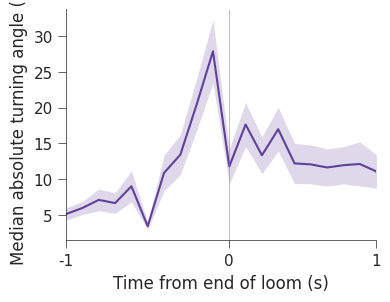

,-1.00s,-0.90s,-0.80s,-0.70s,-0.60s,-0.50s,-0.40s,-0.30s,-0.20s,-0.10s,...,0.10s,0.20s,0.30s,0.40s,0.50s,0.60s,0.70s,0.80s,0.90s,1.00s
0,5.691067,9.140685,41.570048,0.869656,1.716728,3.926049,3.848612,2.030793,2.627018,27.390891,...,3.290394,3.843871,1.045664,2.580512,13.943340,7.452602,4.221970,2.892555,1.363441,14.292832
1,5.736180,0.749780,0.971576,18.817057,0.672926,2.094854,0.992133,2.755541,0.730099,1.669124,...,2.044501,8.529871,0.550219,1.645089,0.616260,2.159180,27.919940,0.985844,0.995563,11.497969
2,1.055534,0.260609,0.199139,0.103188,0.387379,1.999626,1.043567,0.058122,0.476689,147.378337,...,31.775901,3.862407,3.315467,10.673247,14.816565,2.104830,5.675951,21.066023,23.885366,2.090463
3,2.625650,1.623674,4.054557,2.544662,10.741663,6.927829,4.398939,5.577815,3.931854,44.140850,...,3.554882,2.414233,53.355859,11.930159,10.077952,15.282804,1.580268,47.685541,5.498380,0.765592
4,12.111657,21.462901,0.949847,0.364160,3.098062,2.518632,3.584971,4.622479,12.744196,10.991171,...,1.978828,2.657189,0.812685,16.580794,2.360472,8.766705,0.582299,1.328660,9.305396,0.521986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,37.657896,2.522228,0.653987,0.861234,1.975077,1.485233,12.257470,1.724910,1.185160,5.188312,...,2.478172,0.987203,0.563518,1.429367,1.069665,0.174817,0.035780,0.104113,0.137151,0.052961
76,2.881134,2.686633,1.830056,76.323130,0.899239,2.207033,32.851357,1.677431,1.020818,1.719056,...,1.916829,0.326139,1.752007,83.347652,3.296096,8.283639,10.213365,0.997625,1.507779,8.120316
77,0.048252,0.043093,0.059509,0.099324,95.102146,1.864952,4.771892,23.306463,1.119162,2.869009,...,5.916512,1.413964,5.259873,5.353167,0.956011,0.900073,1.196951,1.230378,3.105295,3.757793
78,4.643653,2.884448,43.345770,3.591525,1.135705,1.426256,93.111731,2.236742,2.508843,104.994650,...,3.656446,53.022394,2.466376,61.817305,0.335046,1.770393,4.327643,1.213166,18.597244,2.055672


In [21]:
# metric
metric_name = 'median'; ylabel = 'Median absolute turning angle (°)'

# --- plot ---
plt.figure(figsize=(4,3))
for ig, g in enumerate(group_sizes):
  means = [np.mean([d[metric_name] for d in metrics[g][w]]) for w in window_times]
  sems = [stats.sem(np.concatenate([d[metric_name] for d in metrics[g][w]])) for w in window_times]
  plt.plot(means, color=hex_colors[ig], label=f'{g}-fish')
  plt.fill_between(np.arange(len(means)), [m-s for m, s in zip(means,sems)], [m+s for m, s in zip(means,sems)],\
                   color=hex_colors[ig], alpha=0.2, linewidth=0)
plt.ylabel(ylabel); plt.xlabel('Time from end of loom (s)')
plt.xticks([0,10,19],['-1','0','1']); plt.xlim(0,19)
plt.axvline(10,c='grey',linestyle='-',linewidth=0.5, alpha=0.7)
sns.despine();
subpanel = '1g'
print(figure_path+subpanel)
# plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
plt.show()

# save source data into csv
series_dict = {}
for iw, w_name in enumerate(window_times):
  col_name = f"{w_name}"; tmp = []
  for m in metrics[g][w_name]:
    [tmp.append(entry) for entry in m[metric_name]]
  series_dict[col_name] = pd.Series(tmp)

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# 1h - iid% time series

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/1h


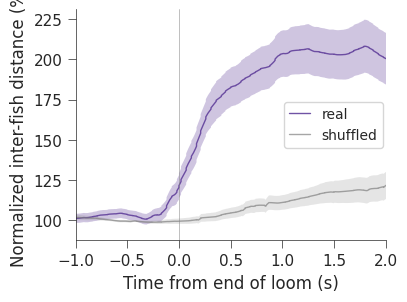

N = [20]
N shuffled = [20]


,real_1,real_2,real_3,real_4,real_5,real_6,real_7,real_8,real_9,real_10,...,shuffled_111,shuffled_112,shuffled_113,shuffled_114,shuffled_115,shuffled_116,shuffled_117,shuffled_118,shuffled_119,shuffled_120
0,119.773614,64.575930,79.843738,86.210215,104.983807,102.299265,99.569698,118.558155,60.958922,108.224351,...,102.874949,155.692245,60.043797,93.664994,116.079068,93.552414,103.802102,113.817231,101.773126,100.247880
1,119.936197,64.373859,80.203303,86.487999,105.029959,101.501395,99.517682,118.657943,62.258704,108.604690,...,102.092675,155.937474,60.651998,93.998252,115.817954,93.799979,103.724165,113.923266,101.508778,99.921333
2,120.085975,64.185082,80.437828,86.766926,105.139873,100.980223,99.736543,118.784621,63.257319,109.000094,...,101.375968,155.858929,61.408349,94.063830,115.255292,94.055200,103.612496,114.026992,101.244083,99.611084
3,120.222229,64.049918,80.633021,86.756414,105.244533,101.180132,100.384031,118.325150,64.525235,109.375242,...,100.734189,155.516847,62.175725,93.835750,114.666900,94.293958,103.486465,113.992416,101.028066,99.531883
4,120.344317,63.911498,80.813969,86.745245,105.351936,101.403525,101.386947,117.556714,65.071104,109.759522,...,100.770404,155.425796,62.896727,93.909644,113.716851,94.319868,103.362576,113.948285,100.821538,99.453690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,226.009878,148.964518,138.022999,46.853064,104.064088,191.493211,162.974682,168.304653,39.587508,106.752942,...,111.434692,110.285561,69.780396,83.135694,68.054933,94.689254,112.101257,64.341547,186.858414,35.957521
359,225.890707,148.945364,136.453972,46.319690,103.786553,191.832288,162.668403,167.973607,39.597381,105.979372,...,111.688732,109.517294,69.566607,82.718066,67.909255,94.886731,112.107811,64.965390,186.815751,35.928426
360,225.787668,148.929843,135.080105,45.804028,103.531577,192.234441,162.282917,167.637948,39.338092,105.445014,...,112.464544,109.109718,69.050188,82.331419,67.947624,95.090215,112.137275,65.571982,186.767245,35.903366
361,225.243720,148.700045,133.497377,45.254381,103.287670,192.693232,161.944453,167.604662,39.355144,105.040402,...,113.230180,108.668730,68.070457,82.383101,67.643076,95.292367,112.141766,66.121787,186.754363,35.869087


In [ ]:
subpanel = '1h'

group_sizes = [4]
group_values = {n: [] for n in group_sizes}
group_values_shuffled = {n: [] for n in group_sizes}  # Add shuffled data storage
hex_colors = ['#61409b']

for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num not in group_sizes: continue

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    scale, fps, frame_num =  data['scale'], data['fps'], data['frame_num']
    f_bodylength_px = data['f_bodylength_px']

    data = np.load(load_path + 'lev0_group_basics.npz', allow_pickle=True)
    f_IID = data['f_IID']
    f_IID_bd = f_IID/np.mean(f_bodylength_px)

    data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
    loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len


    # closest distance - real data
    baseline = [np.mean(dist[loom_off-int(5*fps):loom_off]) for dist in f_IID_bd]
    tmp = [(dist/base) for dist, base in zip(f_IID_bd,baseline)]

    # Create shuffled version
    tmp_shuffled = []
    for dist in f_IID_bd:
      # Roll each timeseries by a random amount
      random_shift = np.random.randint(0, len(dist))
      shuffled_dist = np.roll(dist, random_shift)

      # Calculate baseline after shuffling
      baseline_shuffled = np.mean(shuffled_dist[loom_off-int(1*fps):loom_off])
      tmp_shuffled.append(shuffled_dist/baseline_shuffled)

    # append real data
    pair_num = f_IID.shape[0]
    for f in range(pair_num):
      group_values[fish_num].append(tmp[f][loom_off-int(30*121):loom_off+int(30*121)]*100)
      group_values_shuffled[fish_num].append(tmp_shuffled[f][loom_off-int(30*121):loom_off+int(30*121)]*100)

# make time_sec relative to loom_off for plotting
pre = np.linspace(-30,0,30*121); post = np.linspace(0,30,30*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

# PLOT # mean+sem
plt.figure(figsize=[4,3])
for i, gs in enumerate(group_sizes):
  # Plot real data
  plt.plot(rel_sec,np.mean(group_values[gs],axis=0),linewidth=1,c=hex_colors[i],alpha=0.9,label='real')
  plt.fill_between(rel_sec, np.mean(group_values[gs],axis=0)-scipy.stats.sem(group_values[gs],axis=0), \
                    np.mean(group_values[gs],axis=0)+scipy.stats.sem(group_values[gs],axis=0),color=hex_colors[i],alpha=0.3,linewidth=0)

  # Plot shuffled data in grey
  plt.plot(rel_sec,np.mean(group_values_shuffled[gs],axis=0),linewidth=1,c='grey',alpha=0.7,label='shuffled')
  plt.fill_between(rel_sec, np.mean(group_values_shuffled[gs],axis=0)-scipy.stats.sem(group_values_shuffled[gs],axis=0), \
                    np.mean(group_values_shuffled[gs],axis=0)+scipy.stats.sem(group_values_shuffled[gs],axis=0),color='grey',alpha=0.2,linewidth=0)

plt.axvline(0,c='grey',linestyle='-',linewidth=0.5, alpha=0.7)
plt.legend(bbox_to_anchor=(1,0.5),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
plt.xlim(-1,2);
plt.xlabel('Time from end of loom (s)'); plt.ylabel('Normalized inter-fish distance (%)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f"N = {[int(len(group_values[g])/math.comb(g, 2)) for g in group_sizes]}")
print(f"N shuffled = {[int(len(group_values_shuffled[g])/math.comb(g,2)) for g in group_sizes]}")

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -1, 2; fps = 121

series_dict = {}
for group, samples in group_values.items():
  for i, sample in enumerate(samples):
    col_name = f"real_{i+1}"
    series_dict[col_name] = pd.Series(sample[int((st-ST)*fps):int((ed-ST)*fps)])
for group, samples in group_values_shuffled.items():
  for i, sample in enumerate(samples):
    col_name = f"shuffled_{i+1}"
    series_dict[col_name] = pd.Series(sample[int((st-ST)*fps):int((ed-ST)*fps)])

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# 1i - iid% stats (time shuffle)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/1i


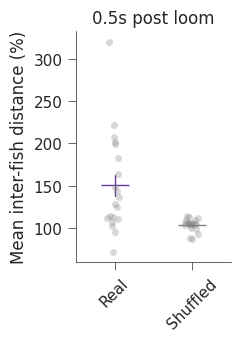

Ns, means, and sems for data:
Real: (N=20) 150.323, 12.969
Shuffled: (N=20) 103.685, 1.624

Normality test (Shapiro-Wilk):
Group Real: W = 0.886, p = 2.2261481775e-02
Group Shuffled: W = 0.896, p = 3.4614425153e-02
not all groups are normally distributed → use nonparametric test.

Mann-Whitney U: U = 336.000, p = 2.4706130132e-04


,real,shuffled
0,143.481015,113.799253
1,114.455402,104.357157
2,136.569161,105.465575
3,125.169836,103.210144
4,110.594554,105.446918
5,112.427175,109.541633
6,148.940957,106.249661
7,128.990989,104.455441
8,201.848963,99.682513
9,102.506235,103.159393


In [ ]:
subpanel = '1i'
window_of_interest = [0.5]

for woi in window_of_interest:

  # DATA
  group_values = {}; shuffled_values = {}
  hex_colors = ['#61409b']

  for exp in experiments[::]:
      load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
      fish_num = metadata.fish_num[exp];
      if fish_num != 4: continue

      # Initialize dictionaries for this fish_num if not exists
      if fish_num not in group_values:
          group_values[fish_num] = []
          shuffled_values[fish_num] = []

      data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
      scale, fps, frame_num =  data['scale'], data['fps'], data['frame_num']
      f_bodylength_px = data['f_bodylength_px']

      data = np.load(load_path + 'lev0_group_basics.npz', allow_pickle=True)
      f_IID = data['f_IID']
      f_IID_bd = f_IID/np.mean(f_bodylength_px)

      data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
      loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len

      # closest distance - real data
      baseline = [np.mean(dist[loom_off-int(1*fps):loom_off]) for dist in f_IID_bd]
      tmp = [(dist/base) for dist, base in zip(f_IID_bd,baseline)]

      # Create shuffled version
      tmp_shuffled = []
      for dist in f_IID_bd:
        # Roll each timeseries by a random amount
        random_shift = np.random.randint(0, len(dist))
        shuffled_dist = np.roll(dist, random_shift)

        # Calculate baseline after shuffling
        baseline_shuffled = np.mean(shuffled_dist[loom_off-int(1*fps):loom_off])
        tmp_shuffled.append(shuffled_dist/baseline_shuffled)

      # get change btw pre and post loom_off
      window = int(fps*woi); dt = 1/fps;
      # delta = [np.trapezoid(t[tap:tap+window],dx=dt) for t in tmp] # auc
      delta = [np.mean(t[loom_off:loom_off+window]) for t in tmp] # mean
      delta_shuffled = [np.mean(t[loom_off:loom_off+window]) for t in tmp_shuffled] # mean for shuffled

      group_values[fish_num].append(np.mean(delta)*100)
      shuffled_values[fish_num].append(np.mean(delta_shuffled)*100)

  # Combine real and shuffled data for plotting
  plot_data = {'Real': group_values[4], 'Shuffled': shuffled_values[4]}

  # plot
  plt.figure(figsize=[2,3])
  sns.stripplot(data=plot_data, color='gray', alpha=0.3, size=5)
  sns.pointplot(data=plot_data, palette=['#61409b', 'gray'], linestyle="none", marker="_",
                estimator='mean', errorbar='se', markersize=20, markeredgewidth=1, errwidth=1)
  plt.xticks(rotation=45); plt.ylabel('Mean inter-fish distance (%)')
  sns.despine(); plt.title(f'{woi}s after loom');
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight')
  plt.show()

  # stats (only proceed if we have data for group size 4)
  groups = ['Real', 'Shuffled']
  summary_data = [group_values[4], shuffled_values[4]]
  print("Ns, means, and sems for data:")
  for id, s in enumerate(summary_data):
    print(f'{groups[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

  ## -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(groups, summary_data):
      stat, p = stats.shapiro(data)
      normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
      print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.10e}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values())
  if is_normal:
      print("all groups are normally distributed → use parametric test.")
  else:
      print("not all groups are normally distributed → use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = len(groups)

  # Two groups: t-test or Mann-Whitney
  if is_normal:
      stat, p = stats.ttest_ind(summary_data[0], summary_data[1])
      print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
  else:
      stat, p = stats.mannwhitneyu(summary_data[0], summary_data[1])
      print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

  # save source data into csv
  series_dict = {}
  series_dict['real'] = pd.Series(group_values[4])
  series_dict['shuffled'] = pd.Series(shuffled_values[4])

  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'.csv', index=False)